# `Paper3_bwm.ipynb` — BDI-M pipeline on the primary dataset (9 barriers)

Original analysis notebook for the manuscript

> **Evaluating the Incorporation of BWM's Importance Weights into DEMATEL-ISM**

This notebook runs the complete **BDI-M** pathway on the primary dataset
(mean direct-relation matrix adapted from Ojha et al., 9 barriers B1–B9,
`primary_direct_relation_matrix_9x9.csv`) with **fixed random seeds**, and
reproduces the corresponding published values exactly:

| Notebook phase | Manuscript item |
|---|---|
| Phase 1 — BWM weight vector | Table III; consistency indicators of Section III.F (ξ\* = 0.0254, CR\_I = 0.0057) |
| Phase 2 — DEMATEL integration (BDI-M) | Table IV (BDI-M columns), Table VI (reclassification of B4, B6; 22.22%) |
| Phase 3 — Thresholds & ISM | Table V (α = 0.177 / 0.007 vs DI 0.502 / 0.179), Table VII (5 levels, σ² = 2.10 / single-level collapse) |
| Phase 4 — Monte Carlo | Fig. 2 statistics (2,000 iterations) and Fig. 3 Stability Index (3,000 iterations per noise level) |

The DI baseline and the BDI-F (8×8) pipeline are covered in `Paper3_2.ipynb`;
the cross-domain validation and convergence diagnostics in `Paper3_3.ipynb`;
`01_full_verification.py` re-checks every published value in one run.

In [1]:
import numpy as np
import pandas as pd
from scipy import stats

np.set_printoptions(suppress=True, precision=3)

labels = [f"B{i}" for i in range(1, 10)]
Z = pd.read_csv("primary_direct_relation_matrix_9x9.csv", index_col=0).values.astype(float)
n = 9
I = np.eye(n)
print("Mean direct-relation matrix Z (Table II):")
print(pd.DataFrame(Z, index=labels, columns=labels))

Mean direct-relation matrix Z (Table II):
      B1    B2    B3    B4    B5    B6    B7    B8    B9
B1  0.00  3.00  3.00  4.00  3.00  1.00  3.00  3.00  3.67
B2  3.00  0.00  3.00  4.00  3.00  2.00  2.67  4.00  3.00
B3  2.33  1.00  0.00  1.33  2.33  3.67  1.00  2.33  2.67
B4  1.00  2.67  1.67  0.00  4.00  3.00  1.00  2.00  2.00
B5  3.00  4.00  3.00  3.00  0.00  3.00  1.33  4.00  2.33
B6  3.00  2.67  3.00  1.33  1.33  0.00  2.67  2.67  2.67
B7  2.33  3.00  1.00  2.33  0.00  0.00  0.00  3.00  1.00
B8  2.33  2.67  2.33  1.67  1.00  1.00  1.33  0.00  3.33
B9  2.00  2.67  3.00  3.00  2.00  2.00  1.00  3.33  0.00


## Phase 1 — Weight derivation (BWM)

The original study (Ojha et al.) did not include a criterion-weighting stage, so the
importance structure over the barrier set was **specified by the research team**
(manuscript, Section III): B2 is the Best criterion, B7 the Worst, and the
Best-to-Others / Others-to-Worst vectors below encode the assumed preference
structure on the standard 1–9 scale (these are the two integer vectors reported in
Section III.F, which also serve as a ready-to-administer questionnaire for a future
expert panel).

The linear BWM (Rezaei, 2016) is solved with the open-source **CBC** solver through
**PuLP**, as stated in Section II.C of the manuscript. The adopted weight vector of
Table III is then compared with the LP solution (Section III.F: Pearson r = 0.960,
Spearman ρ = 0.957; ξ\* = 0.0254; consistency ratio CR\_I = ξ\*/CI(a_BW) = 0.0057,
far below the 0.10 acceptability threshold).

In [2]:
best, worst = 1, 6                                  # B2 = Best, B7 = Worst
aB = np.array([2, 1, 3, 1, 2, 2, 8, 1, 2])          # Best-to-Others  (Section III.F)
aW = np.array([6, 8, 3, 7, 5, 4, 1, 6, 5])          # Others-to-Worst (Section III.F)

def bwm_linear_pulp(aB, aW, best, worst):
    '''Linear BWM (Rezaei 2016): min xi s.t. |wB - aBj wj| <= xi, |wj - ajW wW| <= xi,
    sum w = 1, w >= 0 — solved with CBC via PuLP (scipy fallback).'''
    try:
        import pulp
        prob = pulp.LpProblem("BWM", pulp.LpMinimize)
        xi = pulp.LpVariable("xi", lowBound=0)
        ws = [pulp.LpVariable(f"w{j}", lowBound=1e-6) for j in range(len(aB))]
        prob += xi
        for j in range(len(aB)):
            prob += ws[best] - aB[j] * ws[j] <= xi
            prob += -(ws[best] - aB[j] * ws[j]) <= xi
            prob += ws[j] - aW[j] * ws[worst] <= xi
            prob += -(ws[j] - aW[j] * ws[worst]) <= xi
        prob += pulp.lpSum(ws) == 1
        prob.solve(pulp.PULP_CBC_CMD(msg=0))
        return np.array([v.value() for v in ws]), xi.value()
    except ImportError:
        from scipy.optimize import linprog
        m = len(aB)
        c = np.zeros(m + 1); c[-1] = 1.0
        A_ub = []
        for j in range(m):
            r1 = np.zeros(m + 1); r1[best] = 1; r1[j] += -aB[j]; r1[-1] = -1
            r2 = -r1.copy(); r2[-1] = -1
            r3 = np.zeros(m + 1); r3[j] = 1; r3[worst] += -aW[j]; r3[-1] = -1
            r4 = -r3.copy(); r4[-1] = -1
            A_ub += [r1, r2, r3, r4]
        res = linprog(c, A_ub=A_ub, b_ub=[0.0] * len(A_ub),
                      A_eq=[np.append(np.ones(m), 0.0)], b_eq=[1.0],
                      bounds=[(1e-6, None)] * m + [(0, None)], method="highs")
        return res.x[:m], res.x[-1]

w_lp, xi_star = bwm_linear_pulp(aB, aW, best, worst)

# Rezaei (2015) consistency-index table; CR_I = xi*/CI(a_BW)
CI_TABLE = {1: 0.0, 2: 0.44, 3: 1.00, 4: 1.63, 5: 2.30,
            6: 3.00, 7: 3.73, 8: 4.47, 9: 5.23}
CR_I = xi_star / CI_TABLE[int(aB[worst])]

# Adopted weight vector of the manuscript (Table III) — also in primary_bwm_weights.csv
w9 = np.array([0.121, 0.184, 0.067, 0.148, 0.120, 0.093, 0.022, 0.142, 0.103])
w_csv = pd.read_csv("primary_bwm_weights.csv", index_col=0)["BWM_weight"].values
assert np.allclose(w9, w_csv), "Table III vector must equal primary_bwm_weights.csv"

r_p = stats.pearsonr(w9, w_lp)
r_s = stats.spearmanr(w9, w_lp)

print(f"Best = {labels[best]}, Worst = {labels[worst]}, a_BW = {aB[worst]}")
print(f"a_Bj = {aB.tolist()}")
print(f"a_jW = {aW.tolist()}")
print(f"xi*  = {xi_star:.4f}  ->  consistency ratio CR_I = {CR_I:.4f} "
      f"(threshold 0.10: {'ACCEPTABLE' if CR_I < 0.10 else 'NOT acceptable'})")
print(f"LP solution      : {np.round(w_lp, 3)}")
print(f"Adopted (Table III): {w9}   sum = {w9.sum():.3f}")
print(f"Pearson r (adopted vs LP)  = {r_p.statistic:.4f} (p = {r_p.pvalue:.2e})")
print(f"Spearman rho               = {r_s.statistic:.4f} (p = {r_s.pvalue:.2e})")
print("\nBWM weights (Table III, descending):")
for i in np.argsort(-w9):
    tag = " (Best)" if i == best else (" (Worst)" if i == worst else "")
    print(f"  {labels[i]}{tag:8s} {w9[i]:.3f}")

Best = B2, Worst = B7, a_BW = 8
a_Bj = [2, 1, 3, 1, 2, 2, 8, 1, 2]
a_jW = [6, 8, 3, 7, 5, 4, 1, 6, 5]
xi*  = 0.0254  ->  consistency ratio CR_I = 0.0057 (threshold 0.10: ACCEPTABLE)
LP solution      : [0.102 0.178 0.068 0.174 0.102 0.102 0.021 0.153 0.102]
Adopted (Table III): [0.121 0.184 0.067 0.148 0.12  0.093 0.022 0.142 0.103]   sum = 1.000
Pearson r (adopted vs LP)  = 0.9603 (p = 3.94e-05)
Spearman rho               = 0.9574 (p = 5.03e-05)

BWM weights (Table III, descending):
  B2 (Best)  0.184
  B4         0.148
  B8         0.142
  B1         0.121
  B5         0.120
  B9         0.103
  B6         0.093
  B3         0.067
  B7 (Worst) 0.022


## Phase 2 — DEMATEL integration (BDI-M)

The weighted matrix is Z′ = diag(w)·Z (row *i* scaled by the priority weight
*w<sub>i</sub>*), normalized by the maximum row sum, and the total relation matrix is
T = X(I − X)⁻¹. The prominence (D+R) and relation (D−R) indices below are the
**BDI-M columns of Table IV**; comparing the sign of D−R with the unweighted DI
baseline reproduces the **Table VI** reclassification (B4 and B6; 2/9 = 22.22%).

In [3]:
def total_relation(M):
    X = M / M.sum(axis=1).max()
    return X @ np.linalg.inv(np.eye(len(M)) - X)

T_di  = total_relation(Z)                 # DI baseline (unweighted)
T_bdm = total_relation(w9[:, None] * Z)   # BDI-M (weight-embedded)

D, R   = T_bdm.sum(1), T_bdm.sum(0)
Dd, Rd = T_di.sum(1),  T_di.sum(0)

tab4 = pd.DataFrame({
    "D": D.round(3), "R": R.round(3),
    "D+R": (D + R).round(3), "D-R": (D - R).round(3),
    "Class (BDI-M)": np.where(D - R > 0, "Cause", "Effect"),
    "Class (DI)":    np.where(Dd - Rd > 0, "Cause", "Effect"),
}, index=labels)
print("Table IV — BDI-M columns (with DI classification for comparison):")
print(tab4)

recl = [labels[i] for i in range(n) if (D - R)[i] * (Dd - Rd)[i] < 0]
print(f"\nReclassified barriers (Table VI): {recl}  "
      f"-> rate = {len(recl)}/{n} = {len(recl)/n*100:.2f}%")

Table IV — BDI-M columns (with DI classification for comparison):
        D      R    D+R    D-R Class (BDI-M) Class (DI)
B1  1.250  0.925  2.176  0.325         Cause      Cause
B2  1.908  1.006  2.915  0.902         Cause      Cause
B3  0.498  1.089  1.587 -0.590        Effect     Effect
B4  1.172  1.054  2.226  0.118         Cause     Effect
B5  1.287  0.952  2.238  0.335         Cause      Cause
B6  0.786  0.846  1.633 -0.060        Effect      Cause
B7  0.138  0.777  0.915 -0.639        Effect     Effect
B8  1.001  1.177  2.179 -0.176        Effect     Effect
B9  0.890  1.105  1.995 -0.215        Effect     Effect

Reclassified barriers (Table VI): ['B4', 'B6']  -> rate = 2/9 = 22.22%


## Phase 3 — Threshold selection (MMDE vs MEAN+SD) and ISM partition

Both threshold families are applied to the same BDI-M total relation matrix.
The MMDE implementation is the value-scan mean de-entropy used throughout the
repository (identical to `01_full_verification.py`; an algebraically equivalent
O(m log m) version is benchmarked in `02_R4_supplementary_analysis.py`).
Percent changes are computed on the three-decimal thresholds, as reported in
**Table V**. The ISM level partition (T rounded to three decimals, as in all
notebooks) reproduces the DI and BDI-M rows of **Table VII**.

In [4]:
def mean_sd_threshold(T):
    off = T[~np.eye(T.shape[0], dtype=bool)]
    return off.mean() + off.std()

def mmde_threshold(T):
    v = T[~np.eye(T.shape[0], dtype=bool)]
    v = v[v > 1e-12]
    best_a, best_m = None, -np.inf
    for a in np.sort(np.unique(v)):
        s = v[v >= a]
        if len(s) <= 1:
            m = 0.0
        else:
            p = s / s.sum()
            m = (np.log(len(s)) - (-(p * np.log(p)).sum())) / len(s)
        if m > best_m:
            best_m, best_a = m, a
    return best_a

a = {("DI", "MSD"):  round(mean_sd_threshold(T_di), 3),
     ("DI", "MMDE"): round(mmde_threshold(T_di), 3),
     ("BDM", "MSD"):  round(mean_sd_threshold(T_bdm), 3),
     ("BDM", "MMDE"): round(mmde_threshold(T_bdm), 3)}

print(f"DI     MEAN+SD = {a['DI','MSD']:.3f}   MMDE = {a['DI','MMDE']:.3f}")
print(f"BDI-M  MEAN+SD = {a['BDM','MSD']:.3f}   MMDE = {a['BDM','MMDE']:.3f}")
print("\nTable V (BDI-M rows) — % change vs DI:")
for fam in ("MMDE", "MSD"):
    v = a["BDM", fam]
    print(f"  BDI-M ({fam:7s}) ({v:.3f}):  vs DI MEAN+SD (0.502): "
          f"{(v/a['DI','MSD']-1)*100:+.2f}%   vs DI MMDE (0.179): "
          f"{(v/a['DI','MMDE']-1)*100:+.2f}%")

def ism_levels(T, alpha):
    B = (T >= alpha).astype(int); np.fill_diagonal(B, 1)
    m = len(B)
    reach = [set(np.where(B[i] == 1)[0]) for i in range(m)]
    ante  = [set(np.where(B[:, i] == 1)[0]) for i in range(m)]
    remaining, levels, L = set(range(m)), {}, 1
    while remaining:
        cur = [i for i in remaining
               if reach[i] & remaining == (reach[i] & ante[i]) & remaining]
        if not cur:
            return None
        for i in cur:
            levels[i] = L
        remaining -= set(cur); L += 1
    x = np.array(list(levels.values()), float)
    return len(set(levels.values())), x.mean(), x.var(), levels

print("\nTable VII (DI and BDI-M rows) — ISM partition on T rounded to 3 dp:")
for name, T, alpha in [("DI    (MEAN+SD)", T_di,  a["DI", "MSD"]),
                       ("DI    (MMDE)   ", T_di,  a["DI", "MMDE"]),
                       ("BDI-M (MMDE)   ", T_bdm, a["BDM", "MMDE"]),
                       ("BDI-M (MEAN+SD)", T_bdm, a["BDM", "MSD"])]:
    L, M, V, lv = ism_levels(np.round(T, 3), alpha)
    print(f"  {name} alpha={alpha:<6} levels={L}  mean={M:.2f}  variance={V:.2f}")

L, M, V, lv = ism_levels(np.round(T_bdm, 3), a["BDM", "MSD"])
print("\nBDI-M (MEAN+SD) level assignment:",
      {labels[i]: l for i, l in sorted(lv.items())})

DI     MEAN+SD = 0.502   MMDE = 0.179
BDI-M  MEAN+SD = 0.177   MMDE = 0.007

Table V (BDI-M rows) — % change vs DI:
  BDI-M (MMDE   ) (0.007):  vs DI MEAN+SD (0.502): -98.61%   vs DI MMDE (0.179): -96.09%
  BDI-M (MSD    ) (0.177):  vs DI MEAN+SD (0.502): -64.74%   vs DI MMDE (0.179): -1.12%

Table VII (DI and BDI-M rows) — ISM partition on T rounded to 3 dp:
  DI    (MEAN+SD) alpha=0.502  levels=4  mean=2.00  variance=1.56
  DI    (MMDE)    alpha=0.179  levels=1  mean=1.00  variance=0.00
  BDI-M (MMDE)    alpha=0.007  levels=1  mean=1.00  variance=0.00
  BDI-M (MEAN+SD) alpha=0.177  levels=5  mean=2.11  variance=2.10

BDI-M (MEAN+SD) level assignment: {'B1': 4, 'B2': 5, 'B3': 1, 'B4': 3, 'B5': 2, 'B6': 1, 'B7': 1, 'B8': 1, 'B9': 1}


## Phase 4 — Monte Carlo robustness analysis

Two seeded experiments, identical to the code paths archived in
`03_regenerate_manuscript_figs.py`:

1. **Fig. 2** — distribution of the MEAN+SD threshold under 10% / 15%
   multiplicative Gaussian noise (2,000 iterations per scenario,
   `default_rng(42)`): noise on the rows of Z for DI, on the weight vector for
   BDI-M (re-normalized), as described in Section II.B, Phase 4.
2. **Fig. 3** — Stability Index of BDI-M (9×9), BDI-F (8×8, B7 removed) and DI
   at 5–30% noise (normalize-first formulation, fixed MEAN+SD baseline
   threshold, 3,000 iterations per noise level, `np.random.seed(42)`).

sigma = 10%:  DI mu = 0.489 CV = 9.9%   |   BDI-M mu = 0.184 CV = 16.3%
sigma = 15%:  DI mu = 0.470 CV = 13.3%   |   BDI-M mu = 0.190 CV = 24.7%


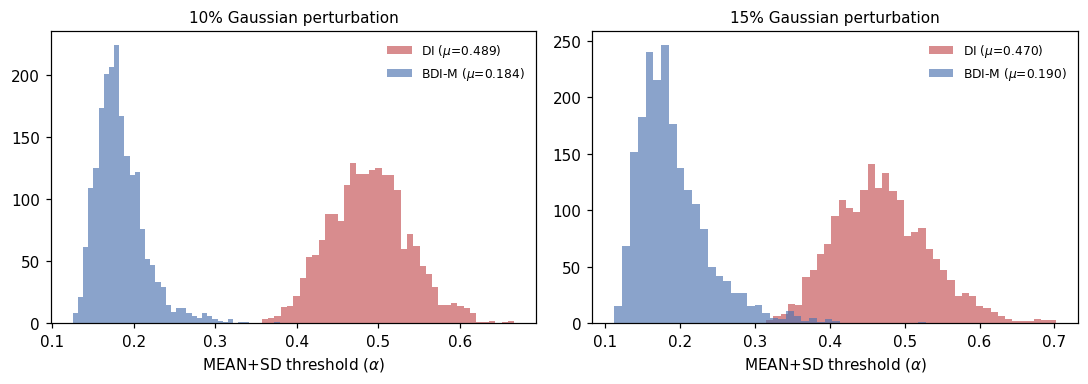

In [5]:
%matplotlib inline
import matplotlib.pyplot as plt

def msd_thr(Zm):
    X = Zm / Zm.sum(axis=1).max()
    T = X @ np.linalg.inv(I - X)
    off = T[~np.eye(n, dtype=bool)]
    return off.mean() + off.std()

def simulate(model, sigma, iters=2000):
    rng = np.random.default_rng(42)
    out = []
    for _ in range(iters):
        if model == "DI":
            Zp = np.maximum(Z * (1 + rng.normal(0, sigma, (n, n))), 0)
            np.fill_diagonal(Zp, 0)
            out.append(msd_thr(Zp))
        else:
            wp = np.maximum(w9 * (1 + rng.normal(0, sigma, n)), 1e-6)
            wp /= wp.sum()
            out.append(msd_thr(wp[:, None] * Z))
    return np.array(out)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), dpi=110)
for ax, sigma in zip(axes, [0.10, 0.15]):
    a_di, a_bdm = simulate("DI", sigma), simulate("BDIM", sigma)
    print(f"sigma = {int(sigma*100)}%:  DI mu = {a_di.mean():.3f} "
          f"CV = {a_di.std()/a_di.mean()*100:.1f}%   |   "
          f"BDI-M mu = {a_bdm.mean():.3f} CV = {a_bdm.std()/a_bdm.mean()*100:.1f}%")
    ax.hist(a_di, bins=40, alpha=0.65, color="#c44e52",
            label=f"DI ($\\mu$={a_di.mean():.3f})")
    ax.hist(a_bdm, bins=40, alpha=0.65, color="#4c72b0",
            label=f"BDI-M ($\\mu$={a_bdm.mean():.3f})")
    ax.set_title(f"{int(sigma*100)}% Gaussian perturbation", fontsize=10)
    ax.set_xlabel(r"MEAN+SD threshold ($\alpha$)")
    ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

sigma = 0.05   BDI-M = 0.2647   BDI-F = 0.0600   DI = 0.0160


sigma = 0.10   BDI-M = 0.0710   BDI-F = 0.0117   DI = 0.0010


sigma = 0.15   BDI-M = 0.0247   BDI-F = 0.0063   DI = 0.0003


sigma = 0.20   BDI-M = 0.0093   BDI-F = 0.0007   DI = 0.0000


sigma = 0.30   BDI-M = 0.0033   BDI-F = 0.0010   DI = 0.0020


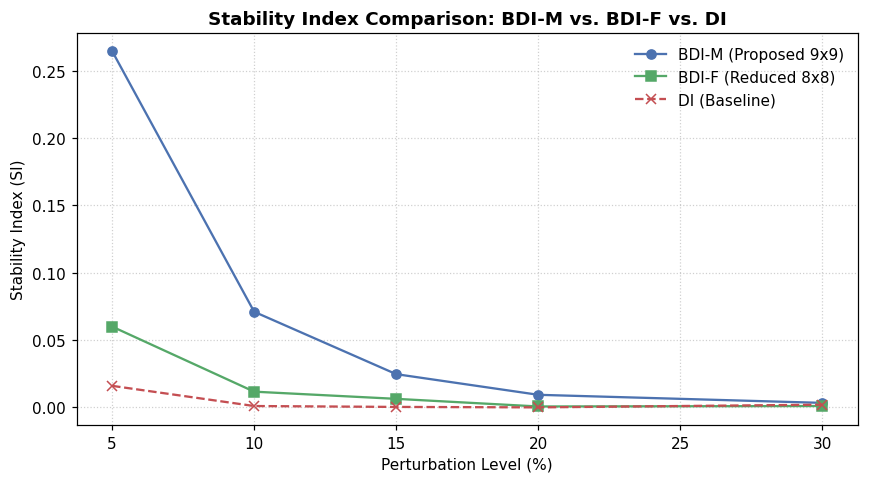

In [6]:
np.random.seed(42)
w8 = np.delete(w9, 6); w8 = w8 / w8.sum()          # BDI-F: B7 removed
A8 = np.delete(np.delete(Z, 6, 0), 6, 1)
D9 = Z / np.max(Z.sum(axis=1))
D8 = A8 / np.max(A8.sum(axis=1))

def run_si_sim(Dm, w_base, is_bdi, sigma, iterations=3000):
    m = Dm.shape[0]; Im = np.eye(m)
    M0 = (np.diag(w_base) @ Dm) if is_bdi else Dm
    T0 = M0 @ np.linalg.inv(Im - M0)
    a0 = mean_sd_threshold(T0)
    R0 = (T0 >= a0).astype(int)
    changes = 0
    for _ in range(iterations):
        noise = np.random.normal(0, sigma, m)
        if is_bdi:
            wp = np.maximum(w_base * (1 + noise), 1e-6); wp /= wp.sum()
            Mk = np.diag(wp) @ Dm
        else:
            Mk = np.maximum(Dm * (1 + noise.reshape(-1, 1)), 0)
        if np.max(np.abs(np.linalg.eigvals(Mk))) >= 1:
            continue
        Tk = Mk @ np.linalg.inv(Im - Mk)
        if not np.array_equal((Tk >= a0).astype(int), R0):
            changes += 1
    return 1 - changes / iterations

noise_levels = [0.05, 0.10, 0.15, 0.20, 0.30]
rows = []
for s in noise_levels:
    rows.append([s * 100,
                 run_si_sim(D9, w9, True, s),
                 run_si_sim(D8, w8, True, s),
                 run_si_sim(D9, w9, False, s)])
    print(f"sigma = {s:.2f}   BDI-M = {rows[-1][1]:.4f}   "
          f"BDI-F = {rows[-1][2]:.4f}   DI = {rows[-1][3]:.4f}")

rows = np.array(rows)
plt.figure(figsize=(8, 4.5), dpi=110)
plt.plot(rows[:, 0], rows[:, 1], "o-",  label="BDI-M (Proposed 9x9)", color="#4c72b0")
plt.plot(rows[:, 0], rows[:, 2], "s-",  label="BDI-F (Reduced 8x8)",  color="#55a868")
plt.plot(rows[:, 0], rows[:, 3], "x--", label="DI (Baseline)",        color="#c44e52")
plt.title("Stability Index Comparison: BDI-M vs. BDI-F vs. DI", fontweight="bold")
plt.xlabel("Perturbation Level (%)"); plt.ylabel("Stability Index (SI)")
plt.legend(frameon=False); plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout(); plt.show()

## Verification against the published values

Every check below must print **PASS** (the same values are re-checked, together
with the DI/BDI-F pipelines and the secondary dataset, by
`01_full_verification.py`).

In [7]:
PASS = lambda ok: "PASS" if ok else "FAIL  <<<"
checks = [
    ("xi* = 0.0254 (Section III.F)",            abs(xi_star - 0.0254) < 5e-4),
    ("CR_I = 0.0057 (Section III.F)",           abs(CR_I - 0.0057) < 5e-4),
    ("Pearson r = 0.960 (Section III.F)",       abs(r_p.statistic - 0.960) < 5e-3),
    ("Spearman rho = 0.957 (Section III.F)",    abs(r_s.statistic - 0.957) < 5e-3),
    ("Table IV: BDI-M D+R(B1) = 2.176",         abs((D + R)[0] - 2.176) < 2e-3),
    ("Table IV: BDI-M D-R(B2) = 0.902",         abs((D - R)[1] - 0.902) < 2e-3),
    ("Table VI: reclassified = B4, B6 (22.22%)", recl == ["B4", "B6"]),
    ("Table V: DI MEAN+SD = 0.502",             a["DI", "MSD"] == 0.502),
    ("Table V: DI MMDE = 0.179",                a["DI", "MMDE"] == 0.179),
    ("Table V: BDI-M MEAN+SD = 0.177",          a["BDM", "MSD"] == 0.177),
    ("Table V: BDI-M MMDE = 0.007",             a["BDM", "MMDE"] == 0.007),
    ("Table VII: BDI-M (MEAN+SD) 5 levels",     L == 5),
    ("Table VII: BDI-M (MEAN+SD) var = 2.10",   abs(V - 2.10) < 0.011),
    ("Table VII: BDI-M (MMDE) collapses to 1 level",
     ism_levels(np.round(T_bdm, 3), a["BDM", "MMDE"])[0] == 1),
]
w = max(len(t) for t, _ in checks)
for t, ok in checks:
    print(f"  {t:<{w}}  {PASS(ok)}")
print("\nAll checks passed." if all(ok for _, ok in checks)
      else "\nSOME CHECKS FAILED — investigate before release.")

  xi* = 0.0254 (Section III.F)                  PASS
  CR_I = 0.0057 (Section III.F)                 PASS
  Pearson r = 0.960 (Section III.F)             PASS
  Spearman rho = 0.957 (Section III.F)          PASS
  Table IV: BDI-M D+R(B1) = 2.176               PASS
  Table IV: BDI-M D-R(B2) = 0.902               PASS
  Table VI: reclassified = B4, B6 (22.22%)      PASS
  Table V: DI MEAN+SD = 0.502                   PASS
  Table V: DI MMDE = 0.179                      PASS
  Table V: BDI-M MEAN+SD = 0.177                PASS
  Table V: BDI-M MMDE = 0.007                   PASS
  Table VII: BDI-M (MEAN+SD) 5 levels           PASS
  Table VII: BDI-M (MEAN+SD) var = 2.10         PASS
  Table VII: BDI-M (MMDE) collapses to 1 level  PASS

All checks passed.
